In [7]:
#importing libraries and loading the dataset
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

import joblib

In [8]:
#loading the dataset
df = pd.read_csv(
    "Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv"
)

In [9]:
#view first rows
df.head()

,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [10]:
#explore the dataset
df.shape

df.columns

df.info()

df.describe()

df.sample(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   flags        26872 non-null  object
 1   instruction  26872 non-null  object
 2   category     26872 non-null  object
 3   intent       26872 non-null  object
 4   response     26872 non-null  object
dtypes: object(5)
memory usage: 1.0+ MB


,flags,instruction,category,intent,response
18133,BLQ,want assistance to notify of a problem with pa...,PAYMENT,payment_issue,I truly appreciate your willingness to seek as...
5736,BL,help me to list the payment options,PAYMENT,check_payment_methods,We'd be delighted to assist you in listing our...
1417,BLZ,edtiing order {{Order Number}},ORDER,change_order,Thank you for contacting us regarding the edit...
20955,BLM,assistance reporting issues with sign-up,ACCOUNT,registration_problems,We appreciate your proactive approach in seeki...
10981,BL,I have a problem with the deletion of a {{Acco...,ACCOUNT,delete_account,We appreciate your inquiry about the deletion ...
13349,BIL,can you show me how soon can I expect the ship...,DELIVERY,delivery_period,We understand your curiosity about the estimat...
15445,BK,getting invoice from {{Person Name}},INVOICE,get_invoice,"I realized, you need assistance with retrievin..."
15130,BKLZ,get bill fromMr. Smith,INVOICE,get_invoice,"I realized, you would like to get a bill from ..."
23291,BILP,where could I set the new shipping address up?,SHIPPING,set_up_shipping_address,Unquestionably! I'm here to assist you in sett...
9849,BLZ,helo to contact an assistant,CONTACT,contact_human_agent,Your input is valuable! I'm picking up that yo...


In [11]:
#handle missing values
df.isnull().sum()

flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64

In [13]:
#remove missing rows if any
df.dropna(inplace=True)

In [14]:
#remove duplicate data
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

0


In [15]:
#keep only required columns
df = df[['instruction','intent','response']]

In [16]:
#explore the target
df.intent.value_counts()

intent
edit_account                1000
switch_account              1000
check_invoice               1000
complaint                   1000
contact_customer_service    1000
delivery_period              999
registration_problems        999
check_payment_methods        999
contact_human_agent          999
payment_issue                999
newsletter_subscription      999
get_invoice                  999
place_order                  998
cancel_order                 998
track_refund                 998
change_order                 997
get_refund                   997
create_account               997
check_refund_policy          997
review                       997
set_up_shipping_address      997
delivery_options             995
delete_account               995
recover_password             995
track_order                  995
change_shipping_address      973
check_cancellation_fee       950
Name: count, dtype: int64

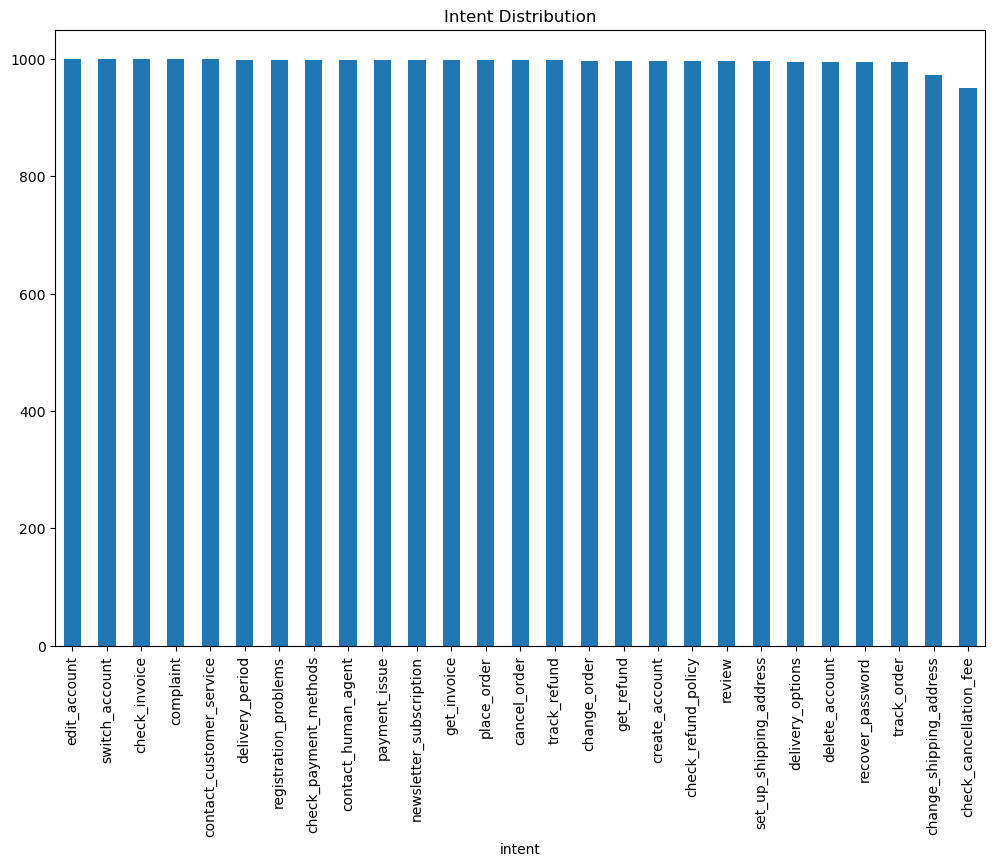

In [17]:
#plot
plt.figure(figsize=(12,8))

df.intent.value_counts().plot(kind="bar")

plt.title("Intent Distribution")

plt.show()

In [18]:
#doing test cleaning
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+","",text)

    text = re.sub(r"\d+","",text)

    text = text.translate(str.maketrans("","",string.punctuation))

    text = text.strip()

    return text

In [19]:
#apply it
df["instruction"] = df["instruction"].apply(clean_text)

In [20]:
#labels and features
#feature
X = df["instruction"]

In [21]:
#target
y = df["intent"]

In [22]:
#label encoding
encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [23]:
#TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=8000,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(X)

In [24]:
#split the dataset
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

In [25]:
#train models
#logic regression
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

In [26]:
#naive bayes
nb = MultinomialNB()

nb.fit(X_train,y_train)

pred_nb = nb.predict(X_test)

In [27]:
#linear SVM
svm = LinearSVC()

svm.fit(X_train,y_train)

pred_svm = svm.predict(X_test)

In [28]:
#random forest
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

In [29]:
#evaluate the accuracy level
print(classification_report(y_test,pred_svm))
print(
accuracy_score(
y_test,
pred_svm
)
)

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       200
           1       0.95      1.00      0.98       199
           2       0.99      1.00      0.99       195
           3       1.00      1.00      1.00       190
           4       0.81      0.87      0.84       200
           5       1.00      1.00      1.00       200
           6       1.00      0.99      0.99       199
           7       1.00      1.00      1.00       200
           8       1.00      0.98      0.99       200
           9       0.99      0.98      0.99       200
          10       0.98      0.98      0.98       199
          11       0.98      1.00      0.99       199
          12       0.99      1.00      1.00       199
          13       1.00      0.99      1.00       200
          14       1.00      1.00      1.00       200
          15       0.86      0.81      0.84       200
          16       0.99      1.00      0.99       199
          17       1.00    

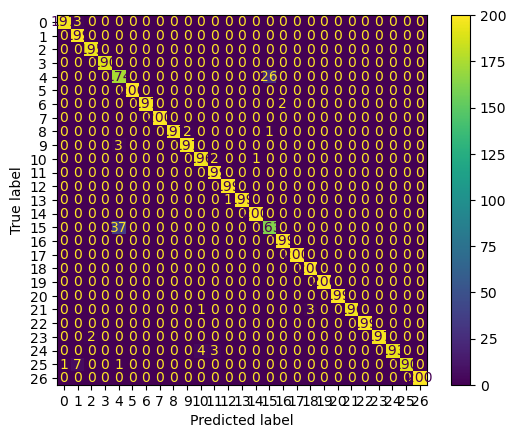

In [30]:
#perform confusion matrix
cm = confusion_matrix(
    y_test,
    pred_svm
)

ConfusionMatrixDisplay(cm).plot()

In [34]:
#compare models
results = pd.DataFrame({

'Model':[
'Logistic Regression',
'Naive Bayes',
'SVM',
'Random Forest'
],

'Accuracy':[

accuracy_score(y_test,pred_lr),

accuracy_score(y_test,pred_nb),

accuracy_score(y_test,pred_svm),

accuracy_score(y_test,pred_rf)

]

})

print(results.sort_values("Accuracy",ascending=False))

                 Model  Accuracy
2                  SVM  0.981395
0  Logistic Regression  0.978047
3        Random Forest  0.976930
1          Naive Bayes  0.976186


In [35]:
#save everything
joblib.dump(svm,"chatbot_model.pkl")

joblib.dump(vectorizer,"vectorizer.pkl")

joblib.dump(encoder,"label_encoder.pkl")

['label_encoder.pkl']

In [36]:
#load the model
model = joblib.load("chatbot_model.pkl")

vectorizer = joblib.load("vectorizer.pkl")

encoder = joblib.load("label_encoder.pkl")

In [37]:
#the prediction function
def predict_intent(text):

    text = clean_text(text)

    vec = vectorizer.transform([text])

    pred = model.predict(vec)

    intent = encoder.inverse_transform(pred)

    return intent[0]

In [38]:
#example
predict_intent("Where is my order?")

'place_order'

In [39]:
#response function
response_dict = (
    df.groupby("intent")["response"]
      .first()
      .to_dict()
)

def chatbot(message):

    intent = predict_intent(message)

    return response_dict[intent]

In [40]:
#example
chatbot("I forgot my password")

'I\'ll get right on it! I can sense your eagerness to regain control over your user profile PIN. \n\nTo reset your PIN, follow these simple steps:\n\n1. Log in to your account on our platform.\n2. Navigate to the account settings or profile settings section.\n3. Look for the option to manage or change your PIN.\n4. Click on the "Reset PIN" option.\n5. Follow any additional instructions or verification steps provided on the screen.\n\nIf you encounter any difficulties or require further assistance during the process, don\'t hesitate to reach out. We\'re here to support you every step of the way!'

In [ ]:
#